In [1]:
import os
import math
import json
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm

from my_transformer import Transformer

In [2]:
# 1. 词表 (字符级)
class Vocabulary:
	"""
    字符级词表
    对联是字符级任务，每个汉字作为一个 token。

    特殊符号:
      <pad> = 0  填充
      <bos> = 1  序列开始 (Begin Of Sequence)
      <eos> = 2  序列结束 (End Of Sequence)
      <unk> = 3  未登录词
    """
	PAD, BOS, EOS, UNK = 0, 1, 2, 3
	PAD_TOKEN = '<pad>'
	BOS_TOKEN = '<bos>'
	EOS_TOKEN = '<eos>'
	UNK_TOKEN = '<unk>'

	def __init__(self):
		self.token2idx = {
			self.PAD_TOKEN : self.PAD,
			self.BOS_TOKEN : self.BOS,
			self.EOS_TOKEN : self.EOS,
			self.UNK_TOKEN : self.UNK,
		}
		self.idx2token = {
			v: k for k, v in self.token2idx.items()
		}

	def build(self, texts, min_freq = 1):
		"""从文本列表构建词表"""
		counter = Counter()
		for text in texts:
			counter.update(list(text.replace(" ", "").strip())) # 字符级分词

		for char, freq in counter.most_common():
			if freq >= min_freq and char not in self.token2idx:
				idx = len(self.token2idx)
				self.token2idx[char] = idx
				self.idx2token[idx] = char
		print(f"词表大小: {len(self.token2idx)}")

	def encode(self, text, add_bos = False, add_eos = False):
		"""文本 → token id 列表"""
		ids = [self.token2idx.get(ch,self.UNK) for ch in text.replace(" ", "").strip()]
		if add_bos:
			ids = [self.BOS] + ids
		if add_eos:
			ids = ids + [self.EOS]
		return ids

	def decode(self, ids, skip_special = True):
		"""token id 列表 → 文本"""
		special = {self.PAD, self.BOS, self.EOS,self.UNK}
		chars = []
		for idx in ids:
			if skip_special and idx in special:
				continue
			chars.append(self.idx2token.get(idx, self.UNK_TOKEN))
		return ''.join(chars)

	def __len__(self):
		return len(self.token2idx)

	def save(self, path):
		with open(path, 'w',encoding='utf-8') as f:
			json.dump(self.token2idx, f, ensure_ascii=False,indent=2)

	@classmethod
	def load(cls, path):
		vocab = cls()
		with open(path,'r',encoding='utf-8') as f:
			vocab.token2idx = json.load(f)
		vocab.idx2token = {int(v): k for k, v in vocab.token2idx.items()}
		return vocab

In [3]:
# 1. 词表 (字符级)案例
src_path = "../datas/couplet/train/in.txt"
tgt_path = "../datas/couplet/train/out.txt"
with open(src_path,"r",encoding='utf-8') as fs , \
		open(tgt_path,"r",encoding='utf-8') as ft:
	train_texts = fs.readlines() + ft.readlines()
vocab_train = Vocabulary()
vocab_train.build(train_texts,1)
vocab_train.save("../datas/couplet/tf_train.json")


词表大小: 9126


In [130]:
# 2. 数据集
class CoupletDataset(Dataset):
	"""
    对联数据集

    每条样本: (上联 token ids, 下联 token ids)
    - 上联作为 encoder 输入 (src)
    - 下联加 <bos>/<eos> 作为 decoder 输入/目标 (tgt)
    """
	def __init__(self,src_path,tgt_path,vocab,max_len = 30):
		self.vocab = vocab
		self.max_len = max_len
		self.data = []

		with open(src_path,'r',encoding='utf-8') as fs, \
			 open(tgt_path,'r',encoding='utf-8') as ft:
			for src_line,tgt_line in zip(fs,ft):
				src_line = src_line.strip()
				tgt_line = tgt_line.strip()
				if not src_line or not tgt_line:
					continue
				if len(src_line) > self.max_len or len(tgt_line) > max_len:
					continue  # 过滤过长句子
				src_ids = self.vocab.encode(src_line)
				tgt_ids = self.vocab.encode(tgt_line, add_bos=True, add_eos=True)
				self.data.append((src_ids, tgt_ids))
		self.data = self.data[:50000]
		print(f"加载 {len(self.data)} 条对联")

	def __len__(self):
		return len(self.data)

	def __getitem__(self, idx):
		return self.data[idx]


In [131]:
# 2. 数据集案例
cd = CoupletDataset(src_path,tgt_path,vocab_train)

加载 50000 条对联


In [132]:
print(vocab_train.decode(cd[0][0],False))
print(vocab_train.decode(cd[0][1],False))
print(cd[0][0])
print(cd[0][1])

晚风摇树树还挺
<bos>晨露润花花更红<eos>
[486, 5, 507, 152, 152, 373, 1582]
[1, 900, 324, 459, 12, 12, 206, 42, 2]


In [133]:
def collate_fn(batch,pad_idx=0):
	"""
    批处理函数: 将变长序列 padding 到同一长度

    返回:
      src: (batch, max_src_len)
      tgt_input: (batch, max_tgt_len-1)  — 去掉最后一个 token
      tgt_label: (batch, max_tgt_len-1)  — 去掉第一个 token (<bos>)
    """
	src_batch, tgt_batch = zip(*batch)

	# Padding
	max_src = max(len(s) for s in src_batch)
	max_tgt = max(len(t) for t in tgt_batch)

	src_padded = torch.zeros(len(batch), max_src, dtype=torch.long)
	tgt_padded = torch.zeros(len(batch), max_tgt, dtype=torch.long)

	for i, (src, tgt) in enumerate(zip(src_batch, tgt_batch)):
		src_padded[i, :len(src)] = torch.tensor(src)
		tgt_padded[i, :len(tgt)] = torch.tensor(tgt)

	# Teacher forcing: tgt_input = tgt[:-1], tgt_label = tgt[1:]
	tgt_input = tgt_padded[:,:-1]
	tgt_label = tgt_padded[:,1:]

	return src_padded, tgt_input, tgt_label

In [134]:
src_padded, tgt_input, tgt_label = collate_fn(cd)

In [135]:
print(src_padded.shape)
print(tgt_input.shape)
print(tgt_label.shape)
print(vocab_train.decode(src_padded[0].numpy(),False))
print(src_padded[0])
print(vocab_train.decode(tgt_input[0].numpy(),False))
print(tgt_input[0])
print(vocab_train.decode(tgt_label[0].numpy(),False))
print(tgt_label[0])

torch.Size([50000, 15])
torch.Size([50000, 16])
torch.Size([50000, 16])
晚风摇树树还挺<pad><pad><pad><pad><pad><pad><pad><pad>
tensor([ 486,    5,  507,  152,  152,  373, 1582,    0,    0,    0,    0,    0,
           0,    0,    0])
<bos>晨露润花花更红<eos><pad><pad><pad><pad><pad><pad><pad>
tensor([  1, 900, 324, 459,  12,  12, 206,  42,   2,   0,   0,   0,   0,   0,
          0,   0])
晨露润花花更红<eos><pad><pad><pad><pad><pad><pad><pad><pad>
tensor([900, 324, 459,  12,  12, 206,  42,   2,   0,   0,   0,   0,   0,   0,
          0,   0])


In [136]:
# 3. 学习率调度 (Noam Schedule)
class NoamScheduler:
	"""
    论文原版 Warmup + 衰减调度
    lr = d_model^(-0.5) · min(step^(-0.5), step · warmup^(-1.5))
    """
	def __init__(self, optimizer, hidden_size, warmup_steps=4000,step_num=0):
		self.optimizer = optimizer
		self.hidden_size = hidden_size
		self.warmup_steps = warmup_steps
		self.step_num = step_num
	def step(self):
		self.step_num += 1
		lr = (self.hidden_size ** -0.5) * min(
            self.step_num ** -0.5,
            self.step_num * self.warmup_steps ** -1.5
        )
		for param_group in self.optimizer.param_groups:
			param_group['lr'] = lr
		return lr

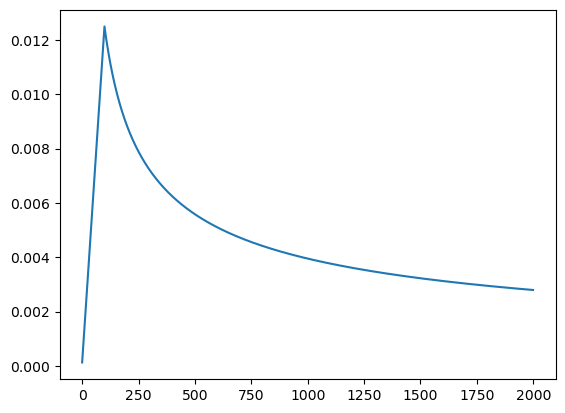

In [137]:
from matplotlib import pyplot as plt
model = Transformer(len(vocab_train), len(vocab_train),64)
optimizer = torch.optim.Adam(model.parameters())
scheduler = NoamScheduler(optimizer,64,100)
lrs = []
for i in range(2000):
	lr = scheduler.step()
	lrs.append(lr)
plt.plot(lrs)
plt.show()

In [138]:
# 4. 标签平滑损失
class LabelSmoothingLoss(nn.Module):
	"""
    标签平滑 CrossEntropy
    防止模型过度自信，提升泛化能力。
    将 one-hot 标签 [0,0,1,0,...] 平滑为 [ε/V, ε/V, 1-ε+ε/V, ...]
    """
	def __init__(self,vocab_size,smoothing=0.1,ignore_index=0):
		super().__init__()
		self.smoothing = smoothing
		self.vocab_size = vocab_size
		self.ignore_index = ignore_index

	def forward(self, logits , targets):
		"""
        logits:  (N, vocab_size)
        targets: (N,)
        """
		log_probs = F.log_softmax(logits,dim=-1)

		# 构造平滑标签分布
		with torch.no_grad():
			smooth_targets = torch.zeros_like(log_probs)
			smooth_targets.fill_(self.smoothing / (self.vocab_size - 2))  # 排除 <pad> 和真实 token
			smooth_targets.scatter_(1,targets.unsqueeze(1),1.0-self.smoothing)
			smooth_targets[:,self.ignore_index] = 0 # pad 位置不赋平滑值
		# mask 掉 padding 位置
		mask = (targets != self.ignore_index)
		loss = -(smooth_targets * log_probs).sum(dim=-1)
		return loss[mask].mean()

In [139]:
# 5. 贪心解码
@torch.no_grad()
def greedy_decode(model:Transformer,src,vocab,max_len=30,device=None):
	"""
    贪心解码: 每步选概率最大的 token
    适合快速推理，但质量不如 beam search
    """
	model.eval()
	src = src.to(device)
	src_mask = model.make_src_mask(src)

	# 编码上联
	src_emb = model.pos_encoding(model.src_embedding(src) * math.sqrt(model.hidden_size))
	enc_output = model.encoder(src_emb,src_mask)

	# 解码：从 <bos> 开始逐步生成
	tgt_ids = [vocab.BOS]
	for _ in range(max_len):
		tgt = torch.tensor([tgt_ids],dtype=torch.long,device=device)
		tgt_mask = model.make_tgt_mask(tgt)

		tgt_emb = model.pos_encoding(model.tgt_embedding(tgt) * math.sqrt(model.hidden_size))
		dec_output = model.decoder(tgt_emb,enc_output,src_mask,tgt_mask)
		logits = model.output_proj(dec_output[:,-1,:])  # 取最后一步的输出

		next_id = logits.argmax(dim=-1).item()
		if next_id == vocab.EOS:
			break
		tgt_ids.append(next_id)

	return vocab.decode(tgt_ids)

In [140]:
# 5. Beam Search
@torch.no_grad()
def beam_search_decode(model:Transformer,src,vocab,beam_size=5,max_len=30,device=None):
	"""
    Beam Search 解码
    维护 beam_size 条候选序列，最终选择总对数概率最高的。

    beam 状态: [(log_prob, token_ids), ...]
    """
	model.eval()
	src = src.to(device)
	src_mask = model.make_src_mask(src)

	src_emb = model.pos_encoding(model.src_embedding(src) * math.sqrt(model.hidden_size))
	enc_output = model.encoder(src_emb,src_mask)  # (1, src_len, d_model)

	# 初始化 beam: 每条 beam = (累计 log_prob, 已生成 ids)
	beams = [(0.0,[vocab.BOS])]
	completed = []

	for _ in range(max_len):
		all_candidates = []

		for log_prob, ids in beams:
			if ids[-1] == vocab.EOS:
				completed.append((log_prob,ids))
				continue
			tgt = torch.tensor([ids], dtype=torch.long,device=device)
			tgt_mask = model.make_tgt_mask(tgt)
			tgt_emb = model.pos_encoding(model.tgt_embedding(tgt) * math.sqrt(model.hidden_size))
			dec_output = model.decoder(tgt_emb,enc_output,src_mask,tgt_mask)
			step_log_probs = F.log_softmax(dec_output[:,-1,:],dim=-1)  # (1, vocab)

			# 取 top beam_size 个候选扩展
			topk_log_probs, topk_ids = step_log_probs[0].topk(beam_size)
			for lp,tid in zip(topk_log_probs.tolist(),topk_ids.tolist()):
				all_candidates.append((log_prob+lp,ids+[tid]))
		if not all_candidates:
			break

		# 按得分排序，保留 top beam_size
		all_candidates.sort(key = lambda x:x[0],reverse=True)
		beams = all_candidates[:beam_size]

	# 合并完成的和未完成的 beam
	completed += beams
	# 长度归一化: 得分 / 序列长度，避免短序列占优
	completed.sort(key = lambda x:x[0] / max(len(x[1]), 1),reverse=True)

	best_ids = completed[0][1]
	return vocab.decode(best_ids)

In [141]:
# 6. 训练函数
def train_epoch(model:Transformer,loader,criterion,scheduler,device,vocab_size,clip_grad = 1.0):
	"""单个 epoch 训练，返回 (平均 loss, 最终 lr)"""
	model.train()
	total_loss = 0.0
	total_tokens = 0
	last_lr = 0.0

	for step,(src,tgt_input,tgt_label) in enumerate(loader):
		src = src.to(device)
		tgt_input = tgt_input.to(device)
		tgt_label = tgt_label.to(device)

		# 前向传播
		logits = model(src,tgt_input) # logits: (batch, tgt_len, vocab_size)

		# 计算 loss (展平成 2D)
		loss = criterion(logits.reshape(-1, vocab_size),tgt_label.reshape(-1))

		# 反向传播
		scheduler.optimizer.zero_grad()
		loss.backward()
		nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
		scheduler.optimizer.step()
		last_lr = scheduler.step() # Noam 学习率更新

		# 统计有效 token 数（非 padding）
		n_tokens = (tgt_label != 0).sum().item()
		total_loss += loss.item() * n_tokens
		total_tokens += n_tokens

		if (step + 1) % 200 == 0:
			print(f"  step {step+1:5d} | loss {loss.item():.4f} | lr {last_lr:.2e}")

	return total_loss / max(total_tokens, 1), last_lr

In [142]:
@torch.no_grad()
def evaluate(model:Transformer,loader,criterion,device,vocab_size):
	model.eval()
	total_loss = 0.0
	total_tokens = 0

	for src, tgt_input,tgt_label in loader:
		src = src.to(device)
		tgt_input = tgt_input.to(device)
		tgt_label = tgt_label.to(device)

		logits = model(src,tgt_input)
		loss = criterion(logits.reshape(-1, vocab_size),tgt_label.reshape(-1))

		n_tokens = (tgt_label != 0).sum().item()
		total_loss += loss.item() * n_tokens
		total_tokens += n_tokens
	return total_loss / max(total_tokens, 1)

In [143]:

def train(args):
	"""完整训练流程"""
	os.makedirs(args.checkpoint_dir, exist_ok=True)
	os.makedirs(args.summary_dir, exist_ok=True)
	device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
	device = torch.device('mps' if torch.mps.is_available() else 'cpu')
	print(f"设备: {device}")

	# ── 7.1 构建词表 ──────────────────────────────────────────
	train_src_path = os.path.join(args.data_dir, "train/in.txt")
	train_tgt_path = os.path.join(args.data_dir, "train/out.txt")
	test_src_path = os.path.join(args.data_dir, "test/in.txt")
	test_tgt_path = os.path.join(args.data_dir, "test/out.txt")
	best_model_path = os.path.join(args.checkpoint_dir,"best_model.pkl")
	last_model_path = os.path.join(args.checkpoint_dir,"last_model.pkl")
	vocab_path = os.path.join(args.data_dir, 'vocab.json')

	if os.path.exists(vocab_path):
		vocab = Vocabulary.load(vocab_path)
		print("vocab已经存在，加载成功!",len(vocab))

	else:
		vocab = Vocabulary()
		all_text = []
		for path in [train_src_path, train_tgt_path]:
			with open(path,"r",encoding="utf-8") as f:
				all_text.extend(f.readlines())
		vocab.build(all_text,1)
		vocab.save(vocab_path)
		print("vocab构建成功!",len(vocab))

	# ── 7.2 数据加载 ──────────────────────────────────────────
	train_dataset = CoupletDataset(train_src_path,train_tgt_path,vocab,args.max_len)
	test_dataset = CoupletDataset(test_src_path,test_tgt_path,vocab,args.max_len)

	train_loader = DataLoader(train_dataset,batch_size=args.batch_size,shuffle=True,collate_fn=collate_fn, pin_memory=True)
	test_loader = DataLoader(test_dataset,batch_size=args.batch_size,shuffle=False,collate_fn=collate_fn)

	# ── 7.3 模型 ──────────────────────────────────────────────
	vocab_size = len(vocab)
	step_num = 0
	model = Transformer(
		src_vocab_size=vocab_size,
		tgt_vocab_size=vocab_size,  # 上下联共享词表
		hidden_size = args.hidden_size,
		num_heads = args.num_heads,
		num_layers = args.num_layers,
		d_ff = args.d_ff,
		max_len = args.max_len + 10,
		dropout = args.dropout,
	).to(device)
	optimizer = torch.optim.Adam(model.parameters(),lr = 0,betas=(0.9,0.98),eps=1e-9)
	total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
	print(f"模型参数量: {total_params:,}")

	if os.path.exists(last_model_path) and args.resume_training:
		print(f"发现历史保存模型 '{last_model_path}'，正在加载...")
		checkpoint = torch.load(last_model_path,map_location=device,weights_only=False)
		model.load_state_dict(checkpoint['model'])
		optimizer.load_state_dict(checkpoint['optimizer'])
		start_epoch = checkpoint["epoch"] + 1
		best_val_loss = checkpoint['val_loss']
		step_num = checkpoint['step_num']
		print(f"成功恢复训练，将从 Epoch {start_epoch} 开始，历史最佳损失: {best_val_loss:.2f}\n")

	# ── 7.4 优化器 & 调度器 ───────────────────────────────────
	scheduler = NoamScheduler(optimizer,args.hidden_size,warmup_steps=args.warmup_steps,step_num=step_num)
	criterion = LabelSmoothingLoss(vocab_size,smoothing=0.1,ignore_index=vocab.PAD)

	# ── 7.5 训练循环 ──────────────────────────────────────────
	writer = SummaryWriter(log_dir=args.summary_dir)
	start_epoch = 0
	best_val_loss = float("inf")



	# 准备几条样例用于过程可视化
	demo_inputs = ["春风送暖入屠苏", "晴空一鹤排云上", "两岸猿声啼不住"]
	print("\n"+"="*60)
	print("开始训练")
	print("="*60)

	for epoch in range(start_epoch+1, start_epoch+args.epochs+1):
		train_pbar = tqdm(train_loader, desc=f'Train Epoch {epoch}/{start_epoch+args.epochs}')
		test_pbar = tqdm(test_loader, desc=f'Test Epoch  {epoch}/{start_epoch+args.epochs}')
		train_loss, lr = train_epoch(model,train_pbar,criterion, scheduler, device, vocab_size)
		val_loss = evaluate(model,test_pbar,criterion,device,vocab_size)

		# PPL (困惑度) = exp(loss)，越低越好
		train_ppl = math.exp(min(train_loss,10))
		val_ppl = math.exp(min(val_loss,10))

		print({"Train Loss":f"{train_loss:.4f}", "PPL": f"{train_ppl:.2f}"})
		print({"Test Loss":f"{val_loss:.4f}", "PPL": f"{val_ppl:.2f}"})
		writer.add_scalar('Train/Loss', train_loss, epoch)
		writer.add_scalar('Train/PPL', train_ppl, epoch)
		writer.add_scalar('Test/Loss', val_loss, epoch)
		writer.add_scalar('Test/PPL', val_ppl, epoch)

		# 展示生成效果
		print("  【实时生成效果】")
		for demo in demo_inputs:
			src_ids = vocab.encode(demo)
			src_tensor = torch.tensor([src_ids],dtype=torch.long,device=device)
			result = greedy_decode(model, src_tensor, vocab, args.max_len, device)
			print(f"    上联: {demo}  →  下联: {result}")

		new_checkpoint = {
                'epoch': epoch,
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'val_loss': val_loss,
                'args': args,
            }

		# 保存最优模型
		if val_loss < best_val_loss:
			best_val_loss = val_loss
			torch.save(new_checkpoint, best_model_path)
			print(f"  ✅ 保存最优模型 → {best_model_path}")

		torch.save(new_checkpoint, last_model_path)
		print(f"  ✅ 保存最后模型 → {last_model_path}")

	writer.close()
	print("\n训练完成！最优验证 Loss:", best_val_loss)

In [144]:
def infer(args):
	"""推理：加载模型，对输入上联生成下联"""
	device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
	device = torch.device('mps' if torch.mps.is_available() else 'cpu')

	# 加载词表
	vocab_path = os.path.join(args.data_dir, 'vocab.json')
	vocab = Vocabulary.load(vocab_path)
	vocab_size = len(vocab)

	# 加载模型
	ckpt = torch.load(args.checkpoint,map_location=device,weights_only=False)
	saved_args = ckpt['args']
	model = Transformer(
		src_vocab_size=vocab_size,
		tgt_vocab_size=vocab_size,
		hidden_size = saved_args.hidden_size,
		num_heads = saved_args.num_heads,
		num_layers = saved_args.num_layers,
		d_ff = saved_args.d_ff,
		max_len = saved_args.max_len+10,
		dropout = 0.0,  # 推理时关闭 dropout
	).to(device)

	model.load_state_dict(ckpt['model'])
	model.eval()
	print(f"加载模型 (Epoch {ckpt['epoch']}, Val Loss {ckpt['val_loss']:.4f})")

	src_ids = vocab.encode(args.input)
	src_tensor = torch.tensor([src_ids],dtype=torch.long,device=device)

	print(f"\n上联: {args.input}")

	# 贪心解码
	greedy_result = greedy_decode(model,src_tensor,vocab,args.max_len,device)
	print(f"下联 (贪心): {greedy_result}")

	# Beam Search 解码
	beam_result = beam_search_decode(model,src_tensor,vocab,5,args.max_len,device)
	print(f"下联 (Beam5): {beam_result}")

In [145]:
# # 8. 数据样例生成器 (无数据集时用于快速测试)
# def generate_demo_date(data_dir,n=500):
# 	"""
#     生成少量示范对联用于快速验证流程（真实训练请使用完整数据集）
#     """
# 	sample_couplets = [
# 		("春风送暖入屠苏", "瑞雪迎春到玉门"),
#         ("爆竹声中一岁除", "梅花香里万家欢"),
#         ("海内存知己", "天涯若比邻"),
#         ("欲穷千里目", "更上一层楼"),
#         ("床前明月光", "窗外秋风凉"),
#         ("举头望明月", "低头思故乡"),
#         ("春眠不觉晓", "夜读不知疲"),
#         ("两岸青山相对出", "一江碧水自东流"),
#         ("日照香炉生紫烟", "风吹杨柳绿成行"),
#         ("千里江山今朝看", "万里长城此时游"),
# 	]
#
# 	# 循环填充到 n 条
# 	pairs = sample_couplets * (n//len(sample_couplets)+1)
# 	pairs = pairs[:n]
#
# 	for split in ['train','test']:
# 		split_dir = os.path.join(data_dir,split)
# 		os.makedirs(split_dir,exist_ok=True)
# 		# 训练集 80%，测试集 20%
# 		subset = pairs[:int(n*0.8)] if split == 'train' else pairs[int(n*0.8):]
# 		with open(os.path.join(split_dir,"in.txt"),"w",encoding="utf-8") as fi, open(os.path.join(split_dir,"out.txt"),"w",encoding="utf-8") as fo:
# 			for src,tgt in subset:
# 				fi.write(src+"\n")
# 				fo.write(tgt+"\n")
# 	print(f"已生成演示数据 → {data_dir}")

In [157]:
class Args():
	model=Transformer
	data_dir= '../datas/couplet'
	checkpoint_dir = '../datas/couplet/model/tf'
	checkpoint= '../datas/couplet/model/tf/best_model.pkl'
	summary_dir = '../datas/couplet/summary/tf'
	resume_training = True
	input= '晴空碧绿'
	hidden_size= 64
	num_heads= 4
	num_layers = 2
	d_ff = 128
	max_len = 30
	dropout = 0.1
	epochs = 200
	batch_size= 64
	warmup_steps = 5000

In [158]:
if __name__ == "__main__":


	args = Args()
	# train(args)
	infer(args)


加载模型 (Epoch 16, Val Loss 4.9721)

上联: 晴空碧绿
下联 (贪心): 野渡青青
下联 (Beam5): 不光万心
